# **PgDip Healthcare Innovation Unit 5: Biomechanics Practical - Forceplate analysis**

This notebook analyses forceplate data from the PgDip Biomechanics lab

## **1. Importing libraries**

In [12]:
# import the required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## **2. Loading the force plate data**

Load the data from the force plate, making sure the data file is in the right folder

In [16]:
jumps = pd.read_csv("data/BIOMECHANICS FORCE PLATE.csv") #this is the data file exported by the forceplate software

## **3. Preview the raw data**

Check the correctness of the data by plotting it on a graph.

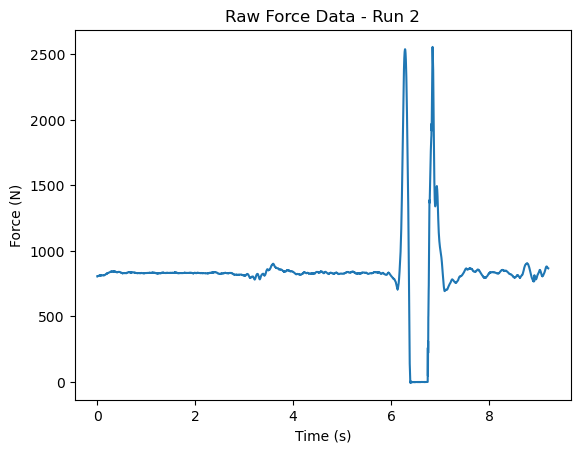

In [20]:
jump_number = 2 # select which run to preview (1-5)

current_jump = pd.DataFrame()
current_jump["Time"] = jumps["Time (s) Run " + str(jump_number)]
current_jump["Force"] = jumps["Vertical Force (N) Run " + str(jump_number)]

plt.plot(current_jump["Time"], current_jump["Force"]) 
plt.xlabel("Time (s)")
plt.ylabel("Force (N)")
plt.title(f"Raw Force Data - Run {jump_number}")
plt.show()

## **4. Analysis functions**

In [23]:
def analyse_jump(jumps, run_number, start_time, end_time, sample_frequency=1000):
    """
    Analyse a single jump to calculate net impulse.
    
    Parameters:
    -----------
    jumps : DataFrame
        Raw CSV data with all runs
    run_number : int
        Which run to analyse (1-5)
    start_time : float
        Start of analysis window (seconds)
    end_time : float
        End of analysis window (seconds)
    sample_frequency : int
        Sampling rate in Hz
    
    Returns:
    --------
    dict : Results including net impulse and phase timings
    """
    
    # Extract Time and Force columns for this run
    current_jump = pd.DataFrame()
    current_jump["Time"] = jumps[f"Time (s) Run {run_number}"]
    current_jump["Force"] = jumps[f"Vertical Force (N) Run {run_number}"]
    
    dt = 1 / sample_frequency
    start = int(start_time * sample_frequency)
    end = int(end_time * sample_frequency)
    
    # Get body weight from quiet standing at the start of the window
    weight = current_jump.loc[start, "Force"]
    
    # Extract jump window and reset time
    just_jump = current_jump.loc[start:end].copy().reset_index(drop=True)
    just_jump["Time"] = just_jump["Time"] - just_jump.loc[0, "Time"]
    
    # Normalise force by body weight
    just_jump["Normalised_force"] = just_jump["Force"] / weight
    
    # Calculate net force (force above body weight)
    just_jump["Net_force"] = just_jump["Normalised_force"] - 1.0
    
    # Takeoff: when force drops below a threshold (near zero)
    takeoff_threshold = 0.1  # 10% of body weight
    below_threshold = just_jump[just_jump["Normalised_force"] < takeoff_threshold]
    
    if len(below_threshold) > 0:
        takeoff_idx = below_threshold.index[0]
    else:
        takeoff_idx = len(just_jump) - 1
        print("Warning: Takeoff not detected - check your time window")
    
    # Find start of propulsive phase (first time net force becomes positive)
    propulsive_data = just_jump.loc[:takeoff_idx].copy()
    negative_to_positive = propulsive_data[propulsive_data["Net_force"] > 0]
    if len(negative_to_positive) > 0:
        propulsive_start_idx = negative_to_positive.index[0]
    else:
        propulsive_start_idx = 0
    
    # Calculate net impulse using trapezoidal integration
    propulsive_phase = just_jump.loc[propulsive_start_idx:takeoff_idx]
    net_impulse = np.trapz(propulsive_phase["Net_force"], dx=dt)
    total_impulse = np.trapz(propulsive_phase["Normalised_force"], dx=dt)
    peak_force = propulsive_phase["Normalised_force"].max()
    propulsive_duration = len(propulsive_phase) * dt
    
    return {
        "net_impulse_BWs": net_impulse,
        "total_impulse_BWs": total_impulse,
        "peak_force_BW": peak_force,
        "propulsive_duration_s": propulsive_duration,
        "takeoff_time_s": just_jump.loc[takeoff_idx, "Time"],
        "propulsive_start_time_s": just_jump.loc[propulsive_start_idx, "Time"],
        "data": just_jump,
        "propulsive_phase": propulsive_phase,
        "takeoff_idx": takeoff_idx,
        "propulsive_start_idx": propulsive_start_idx,
        "weight_N": weight
    }


def plot_jump_analysis(results, title="Jump Analysis", save_prefix=None):
    """Create visualisation of the jump analysis showing normalised force."""
    
    data = results["data"]
    prop_start = results["propulsive_start_idx"]
    takeoff = results["takeoff_idx"]
    prop_phase = data.loc[prop_start:takeoff]
    
    textstr = (f"Net Impulse: {results['net_impulse_BWs']:.4f} BW·s\n"
               f"Peak Force: {results['peak_force_BW']:.2f} BW\n"
               f"Propulsive Duration: {results['propulsive_duration_s']*1000:.1f} ms")
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(data["Time"], data["Normalised_force"], 'b-', linewidth=1, label='Normalised Force')
    ax.axhline(y=1.0, color='gray', linestyle='--', label='Body Weight (1.0 BW)')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.fill_between(prop_phase["Time"], prop_phase["Normalised_force"], 1.0,
                    where=prop_phase["Normalised_force"] > 1.0,
                    alpha=0.3, color='green', label='Net Positive Impulse')
    ax.fill_between(prop_phase["Time"], prop_phase["Normalised_force"], 1.0,
                    where=prop_phase["Normalised_force"] < 1.0,
                    alpha=0.3, color='red', label='Net Negative Impulse')
    ax.axvline(x=data.loc[prop_start, "Time"], color='green', linestyle=':', label='Propulsive Start')
    ax.axvline(x=data.loc[takeoff, "Time"], color='red', linestyle=':', label='Takeoff')
    ax.set_ylim(0, 3.5)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Normalised Force (BW)")
    ax.set_title(title)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.text(0.02, 0.02, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='bottom', bbox=props)
    
    fig.tight_layout()
    if save_prefix:
        fig.savefig(f"{save_prefix}.png", dpi=150, bbox_inches='tight')
        print(f"Saved: {save_prefix}.png")
    
    plt.show()
    return fig


def compare_jumps(results_dict):
    """Compare multiple jumps and return a summary table."""
    comparison = []
    for condition, results in results_dict.items():
        comparison.append({
            "Condition": condition,
            "Net Impulse (BW·s)": round(results["net_impulse_BWs"], 4),
            "Peak Force (BW)": round(results["peak_force_BW"], 2),
            "Propulsive Duration (ms)": round(results["propulsive_duration_s"] * 1000, 1)
        })
    return pd.DataFrame(comparison).set_index("Condition")

## **5. Jump configuration**

Define which run corresponds to each squat depth condition, and the time window for each jump. Adjust the `run_number`, `start_time`, and `end_time` values as needed.

In [26]:
# Each entry: (run_number, start_time, end_time)
jump_configs = {
    "Quarter":        {"run": 2, "start": 6.0, "end": 6.7},
    "Half":           {"run": 3, "start": 4.2, "end": 4.9},
    "Three Quarters": {"run": 4, "start": 4.1, "end": 4.8},
    "Full":           {"run": 5, "start": 1.6, "end": 2.3},
}

## **6. Analyse all jumps**

Run the analysis and plot results for each squat depth condition.


Analysing: Quarter squat jump (Run 2)
  Body weight: 808.9 N
  Net Impulse: 0.2182 BW·s
  Peak Force:  3.14 BW
Saved: plots/jump_quarter.png


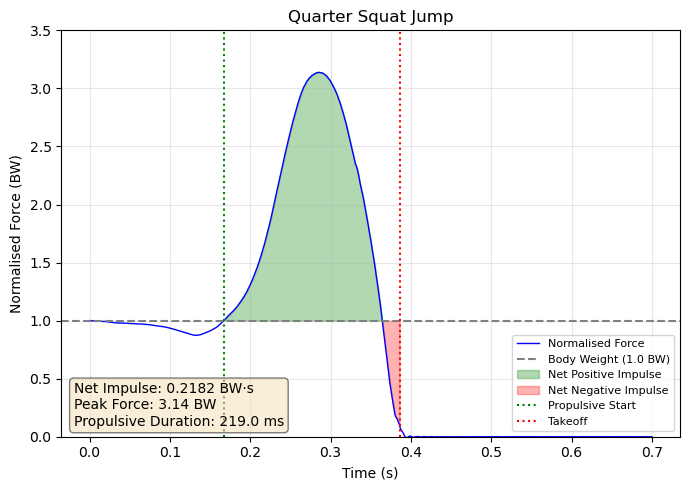


Analysing: Half squat jump (Run 3)
  Body weight: 853.0 N
  Net Impulse: 0.2315 BW·s
  Peak Force:  2.36 BW
Saved: plots/jump_half.png


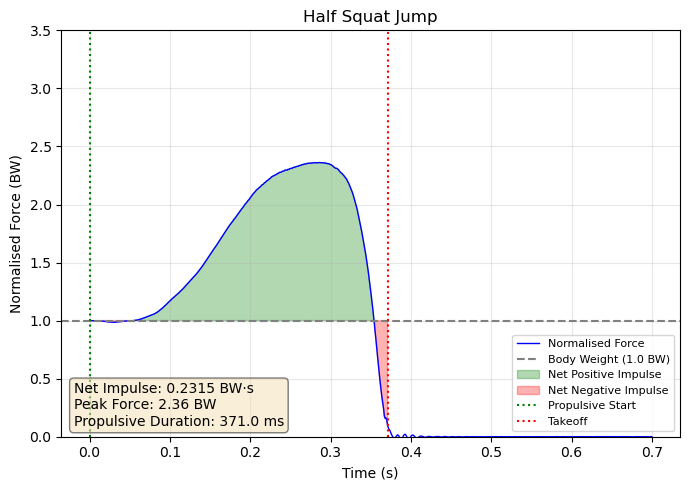


Analysing: Three Quarters squat jump (Run 4)
  Body weight: 812.5 N
  Net Impulse: 0.2860 BW·s
  Peak Force:  1.95 BW
Saved: plots/jump_three_quarters.png


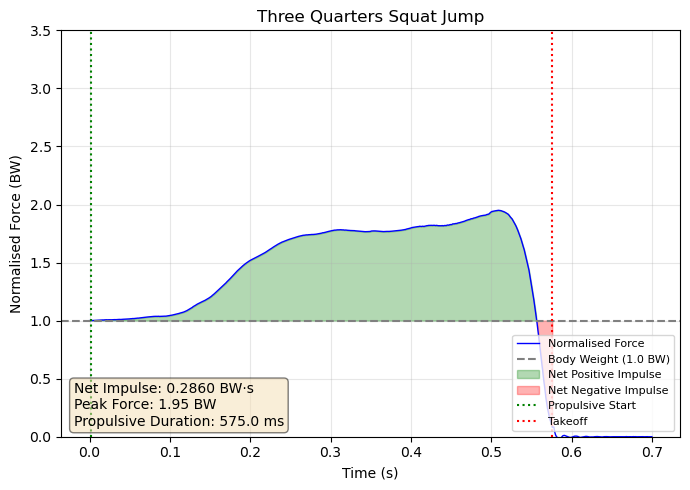


Analysing: Full squat jump (Run 5)
  Body weight: 828.2 N
  Net Impulse: 0.2824 BW·s
  Peak Force:  1.87 BW
Saved: plots/jump_full.png


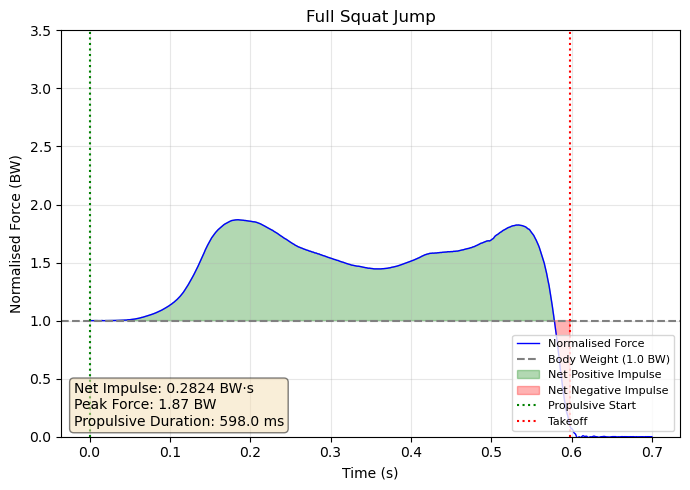

In [29]:
all_results = {}

for condition, config in jump_configs.items():
    print(f"\n{'='*60}")
    print(f"Analysing: {condition} squat jump (Run {config['run']})")
    print(f"{'='*60}")
    
    results = analyse_jump(jumps, config["run"], config["start"], config["end"])
    all_results[condition] = results
    
    print(f"  Body weight: {results['weight_N']:.1f} N")
    print(f"  Net Impulse: {results['net_impulse_BWs']:.4f} BW·s")
    print(f"  Peak Force:  {results['peak_force_BW']:.2f} BW")
    
    plot_jump_analysis(results, title=f"{condition} Squat Jump", save_prefix=f"plots/jump_{condition.lower().replace(' ', '_')}")

## **7. Comparison across conditions**

                Net Impulse (BW·s)  Peak Force (BW)  Propulsive Duration (ms)
Condition                                                                    
Quarter                     0.2182             3.14                     219.0
Half                        0.2315             2.36                     371.0
Three Quarters              0.2860             1.95                     575.0
Full                        0.2824             1.87                     598.0



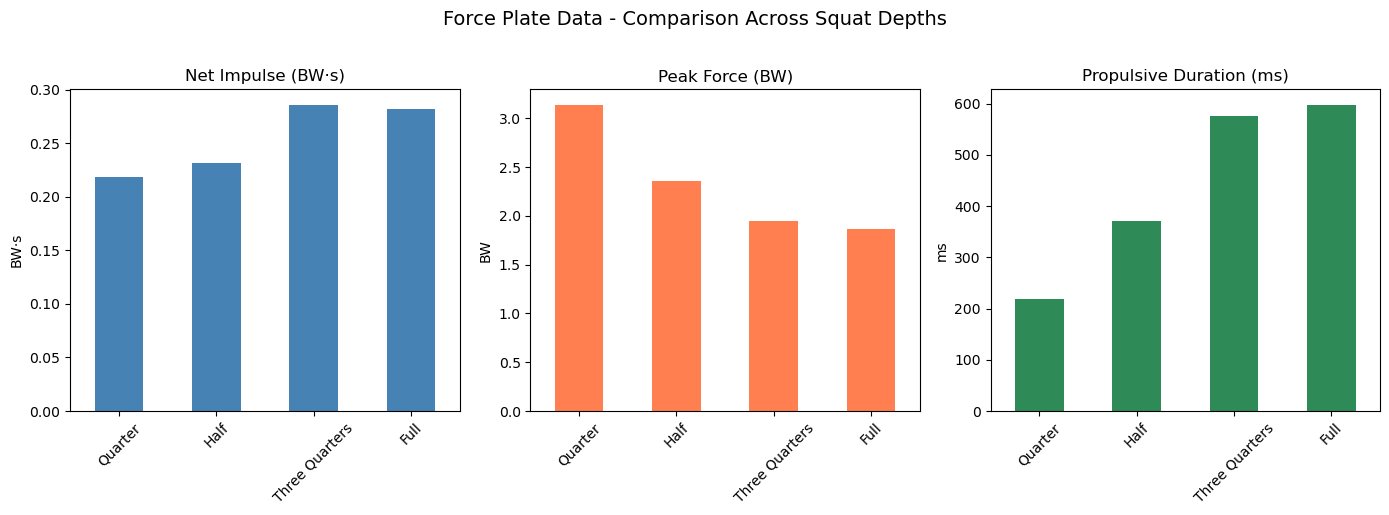

In [37]:
comparison = compare_jumps(all_results)
print(comparison)
print()

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

comparison["Net Impulse (BW·s)"].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("Net Impulse (BW·s)")
axes[0].set_ylabel("BW·s")

comparison["Peak Force (BW)"].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title("Peak Force (BW)")
axes[1].set_ylabel("BW")

comparison["Propulsive Duration (ms)"].plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title("Propulsive Duration (ms)")
axes[2].set_ylabel("ms")

for ax in axes:
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)

fig.suptitle("Force Plate Data - Comparison Across Squat Depths", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

                Net Impulse (BW·s)  Peak Force (BW)  Propulsive Duration (ms)
Condition                                                                    
Quarter                     0.2182             3.14                     219.0
Half                        0.2315             2.36                     371.0
Three Quarters              0.2860             1.95                     575.0
Full                        0.2824             1.87                     598.0



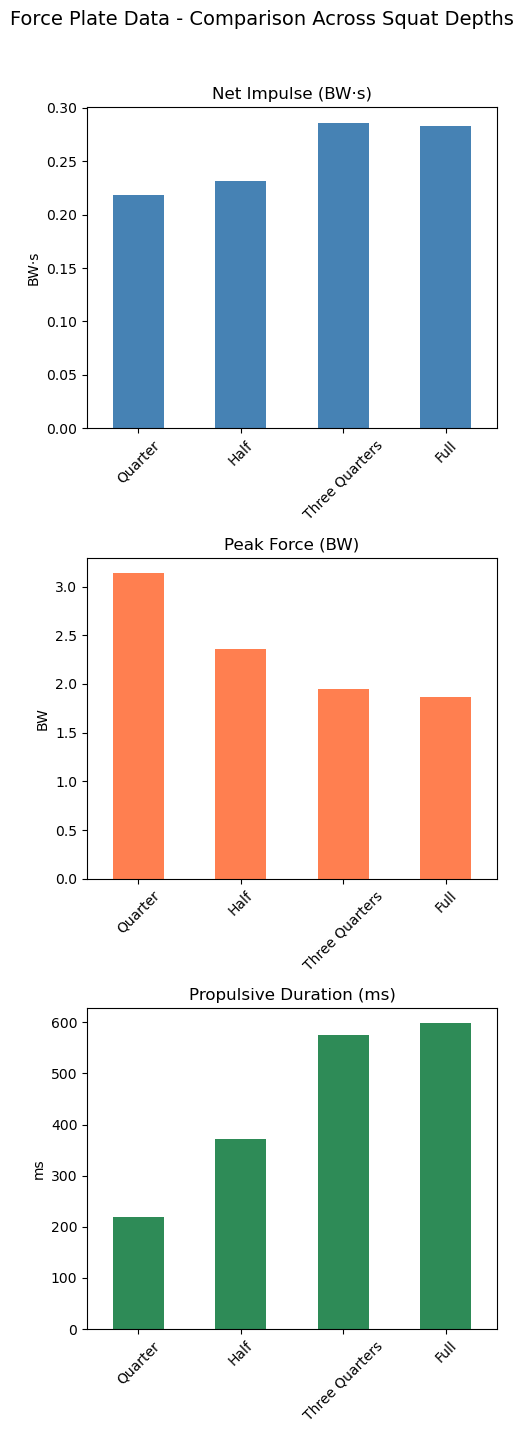

In [39]:
comparison = compare_jumps(all_results)
print(comparison)
print()

# Bar chart comparison
fig, axes = plt.subplots(3, 1, figsize=(5, 14))

comparison["Net Impulse (BW·s)"].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("Net Impulse (BW·s)")
axes[0].set_ylabel("BW·s")

comparison["Peak Force (BW)"].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title("Peak Force (BW)")
axes[1].set_ylabel("BW")

comparison["Propulsive Duration (ms)"].plot(kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title("Propulsive Duration (ms)")
axes[2].set_ylabel("ms")

for ax in axes:
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)

fig.suptitle("Force Plate Data - Comparison Across Squat Depths", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()